<a href="https://colab.research.google.com/github/siddhartha-sai-17/Machine_Learning/blob/main/K_Means_Clustering(Wholesale_customer_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv


In [4]:
df = pd.read_csv('Wholesale customers data.csv')

In [5]:
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [6]:
df.isna().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [39]:
X = df.iloc[:, 2:].values

In [40]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)


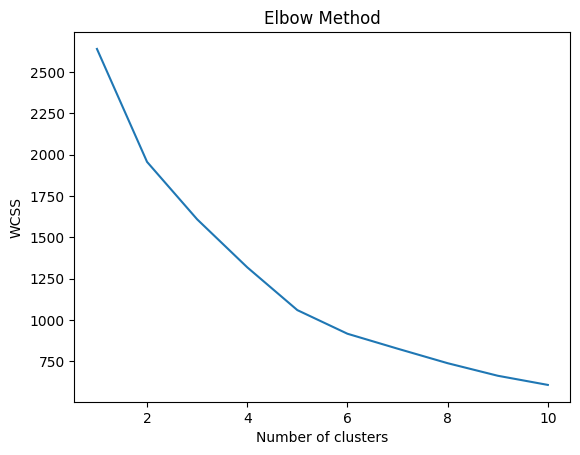

In [42]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


In [43]:
kmeans = KMeans(n_clusters= 5, init = 'k-means++' , random_state = 0)
y_kmeans = kmeans.fit_predict(X)

In [44]:
y_kmeans

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 4, 4, 1, 0, 0, 0, 1, 4, 1, 0, 1, 0, 1,
       0, 2, 0, 0, 1, 1, 4, 0, 0, 1, 0, 0, 1, 4, 0, 4, 4, 3, 0, 0, 4, 4,
       1, 4, 4, 2, 1, 4, 1, 1, 0, 4, 0, 1, 4, 4, 1, 1, 1, 2, 1, 4, 1, 2,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 4, 1, 1, 1, 4, 4, 0, 1, 2, 2, 3,
       1, 0, 1, 1, 2, 1, 4, 1, 1, 1, 1, 1, 4, 4, 1, 3, 1, 0, 4, 4, 1, 4,
       1, 4, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 3, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 4, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 4, 4, 0, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 1, 1, 4, 4, 1, 4, 1, 4,
       3, 1, 1, 1, 1, 3, 4, 3, 1, 1, 1, 1, 4, 4, 0, 1, 1, 4, 1, 0, 0, 4,
       1, 1, 4, 4, 0, 1, 1, 4, 1, 1, 1, 4, 0, 2, 1, 1, 4, 4, 4, 0, 4, 1,
       1, 4, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 3, 0, 0,
       0, 1, 4, 4, 1, 1, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 3, 3, 1, 1, 0, 1,
       4, 4, 4, 0, 4, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 3, 0, 3, 0,
       1, 0, 0, 0, 1, 1, 1, 4, 0, 1, 0, 1, 1, 1, 0,

In [35]:
print(df.columns)


Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')


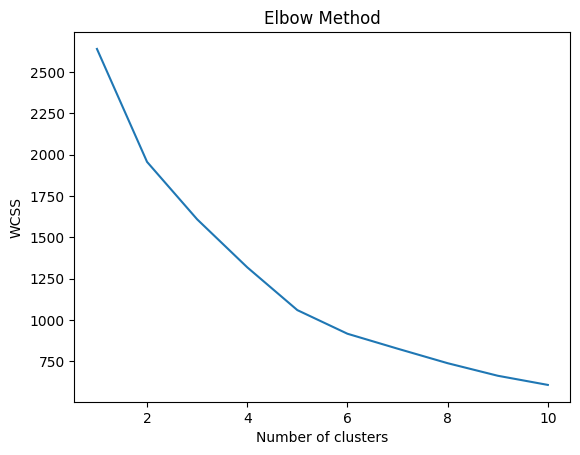

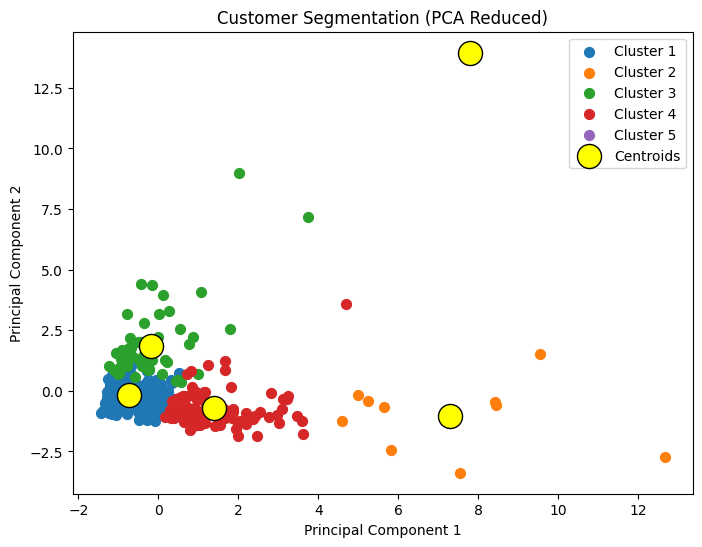

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
dataset = pd.read_csv("Wholesale customers data.csv")

# Use only numerical spending features
X = dataset[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].values

# Scale data
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# Elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# Train final model (assume k = 5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform centroids too
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(8, 6))

for i in range(5):
    plt.scatter(X_pca[y_kmeans == i, 0], X_pca[y_kmeans == i, 1], s=50, label=f'Cluster {i+1}')

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=300, c='yellow', edgecolors='black', label='Centroids')

plt.title("Customer Segmentation (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()
